# Face Modality (Ablation) — Pure Facial Features, No Eye Region

**Driver Fatigue Detection — Signal Modality Comparison**
*BSc Computing Dissertation — Leon Dupree*

## Purpose

This notebook is a **follow-up experiment** to `02_face_training.ipynb`. It
trains the same MLP architecture on the same DDD dataset, but **excludes
the two eye-region features** (`ear_avg` and `eye_distance_norm`).

### Motivation

Permutation importance analysis on the full face model revealed that EAR
(Eye Aspect Ratio) was by far the strongest predictor (20.7 percentage
point drop when shuffled), with the second strongest also being eye-region
(`eye_distance_norm`, 10.7 points). This raises a methodological question
already flagged in the literature review (§2.5):

> *"Many so-called facial detection systems include the eye region within
> their models. If ocular behaviour already provides strong predictive
> power, improvements attributed to full-face analysis may largely reflect
> underlying eyelid dynamics."*

This ablation tests that hypothesis empirically. By removing the eye-region
features and retraining with **only** head pose (pitch, yaw, roll) and
mouth aspect ratio (MAR), we obtain a "true face" baseline that quantifies
how much of the face model's apparent performance is actually driven by
ocular cues rather than by broader facial behaviour.

### Setup

This notebook **reuses** the cached features at `data/face_features.csv`
written by `02_face_training.ipynb`. If that cache doesn't exist, run the
main face notebook first.

The trained weights here are saved to `models/face_mlp_no_eye.pt` so they
do not overwrite the main face model.


## 1. Setup and imports

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.face.model import FaceMLP

print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")


PyTorch: 2.5.1+cu121
CUDA:    True


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## 2. Load cached features from the main face notebook

The features were already extracted and saved when you ran `02_face_training.ipynb`.
We reuse them here — no need to re-run MediaPipe over 8,000 images.


In [3]:
CACHE_PATH = PROJECT_ROOT / "data" / "face_features.csv"

if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f"Cached features not found at {CACHE_PATH}.\n"
        "Please run 02_face_training.ipynb first to generate them."
    )

df = pd.read_csv(CACHE_PATH)
print(f"Loaded {len(df):,} rows from cache")
print(f"\nClass balance:")
print(df["label"].value_counts().rename({0: "non_drowsy", 1: "drowsy"}))
df.head()


Loaded 7,995 rows from cache

Class balance:
label
non_drowsy    3998
drowsy        3997
Name: count, dtype: int64


,pitch,yaw,roll,mar,ear_avg,eye_distance_norm,label,path
0,-174.378171,4.302496,1.772324,0.006946,0.172550,0.632097,1,C:\Dissertation\fatigue-detection\data\Driver ...
1,-179.189527,1.463237,2.163743,0.002488,0.223230,0.555935,1,C:\Dissertation\fatigue-detection\data\Driver ...
2,-171.077949,3.346962,-0.525998,0.004311,0.265837,0.603700,1,C:\Dissertation\fatigue-detection\data\Driver ...
3,167.146761,-5.513819,3.029522,0.010930,0.205317,0.481710,1,C:\Dissertation\fatigue-detection\data\Driver ...
4,166.044057,-5.660322,3.636231,0.002306,0.187279,0.565337,1,C:\Dissertation\fatigue-detection\data\Driver ...


## 3. Select non-eye features only

We **keep** head pose (pitch, yaw, roll) and mouth aspect ratio (MAR).
We **drop** the eye aspect ratio (EAR) and the inter-eye distance.

This gives a 4-feature input — half the dimensionality of the main face
model, which already removes some capacity. To keep the comparison clean,
the model architecture, hyperparameters, and training schedule remain
identical to `02_face_training.ipynb`.


In [4]:
# Main notebook used these features
ALL_FEATURES = ["pitch", "yaw", "roll", "mar", "ear_avg", "eye_distance_norm"]

# This notebook uses only the non-eye subset
FEATURE_COLS = ["pitch", "yaw", "roll", "mar"]

print("Features used in this ablation:")
for f in FEATURE_COLS:
    print(f"  - {f}")

print("\nFeatures EXCLUDED (eye-region):")
for f in set(ALL_FEATURES) - set(FEATURE_COLS):
    print(f"  - {f}")

print(f"\nFeature dimensionality: {len(FEATURE_COLS)} (vs {len(ALL_FEATURES)} in main face model)")


Features used in this ablation:
  - pitch
  - yaw
  - roll
  - mar

Features EXCLUDED (eye-region):
  - ear_avg
  - eye_distance_norm

Feature dimensionality: 4 (vs 6 in main face model)


## 4. Train / validation / test split

We use the **same SEED, same stratification, same proportions** as the
main face notebook. This ensures the train/val/test partitions are
identical at the row level — only the features differ. Any difference in
test performance is therefore attributable to the feature set, not to
sampling variance.


In [5]:
X = df[FEATURE_COLS].to_numpy(dtype=np.float32)
y = df["label"].to_numpy(dtype=np.int64)

# 70/15/15, stratified, same seed as main notebook
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15 / 0.85, random_state=SEED, stratify=y_tv
)

# Standardise using training set statistics
mu  = X_train.mean(axis=0, keepdims=True)
sig = X_train.std(axis=0, keepdims=True) + 1e-6
X_train = (X_train - mu) / sig
X_val   = (X_val - mu) / sig
X_test  = (X_test - mu) / sig

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print(f"\nTrain class balance: {np.bincount(y_train)}")
print(f"Val class balance:   {np.bincount(y_val)}")
print(f"Test class balance:  {np.bincount(y_test)}")


Train: 5,595  Val: 1,200  Test: 1,200

Train class balance: [2798 2797]
Val class balance:   [600 600]
Test class balance:  [600 600]


In [8]:
def make_loader(X_arr, y_arr, batch_size, shuffle):
    ds = TensorDataset(torch.tensor(X_arr), torch.tensor(y_arr))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 128
train_dl = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_dl   = make_loader(X_val,   y_val,   BATCH_SIZE, shuffle=False)
test_dl  = make_loader(X_test,  y_test,  BATCH_SIZE, shuffle=False)


## 5. Model and training

Same `FaceMLP` architecture as the main notebook. Same dropout, same
learning rate, same number of epochs. Only the input dimensionality
changes (4 features instead of 6).


In [9]:
N_FEATURES = X_train.shape[1]
model = FaceMLP(n_features=N_FEATURES, num_classes=2, dropout=0.25).to(DEVICE)
print(model)
print(f"\nTrainable parameters: {model.count_parameters():,}")


FaceMLP(
  (classifier): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=16, out_features=2, bias=True)
  )
)

Trainable parameters: 722


In [10]:
EPOCHS = 30
LEARNING_RATE = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.CrossEntropyLoss()

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
BEST_WEIGHTS_PATH = MODELS_DIR / "face_mlp_no_eye.pt"

# Save the normalisation stats with a different name too
np.save(MODELS_DIR / "face_mlp_no_eye_norm_mu.npy",  mu.squeeze())
np.save(MODELS_DIR / "face_mlp_no_eye_norm_sig.npy", sig.squeeze())

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0


def run_epoch(loader, training: bool):
    model.train(training)
    total_loss, total_correct, total_n = 0.0, 0, 0
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = loss_fn(logits, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(1) == y).sum().item()
            total_n += x.size(0)
    return total_loss / total_n, total_correct / total_n


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_dl, training=True)
    val_loss, val_acc = run_epoch(val_dl, training=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_WEIGHTS_PATH)
        marker = "  <- best, saved"

    print(f"Epoch {epoch:2d}/{EPOCHS}  "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.3f}  "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}{marker}")

print(f"\nBest validation accuracy: {best_val_acc:.3f}")
print(f"Saved best weights to: {BEST_WEIGHTS_PATH}")


Epoch  1/30  train_loss=0.6894 train_acc=0.529  val_loss=0.6709 val_acc=0.592  <- best, saved
Epoch  2/30  train_loss=0.6693 train_acc=0.579  val_loss=0.6514 val_acc=0.602  <- best, saved
Epoch  3/30  train_loss=0.6547 train_acc=0.592  val_loss=0.6354 val_acc=0.623  <- best, saved
Epoch  4/30  train_loss=0.6408 train_acc=0.624  val_loss=0.6220 val_acc=0.657  <- best, saved
Epoch  5/30  train_loss=0.6313 train_acc=0.625  val_loss=0.6144 val_acc=0.655
Epoch  6/30  train_loss=0.6263 train_acc=0.628  val_loss=0.6095 val_acc=0.655
Epoch  7/30  train_loss=0.6219 train_acc=0.630  val_loss=0.6041 val_acc=0.668  <- best, saved
Epoch  8/30  train_loss=0.6138 train_acc=0.647  val_loss=0.6002 val_acc=0.673  <- best, saved
Epoch  9/30  train_loss=0.6106 train_acc=0.649  val_loss=0.6010 val_acc=0.667
Epoch 10/30  train_loss=0.6090 train_acc=0.657  val_loss=0.5963 val_acc=0.678  <- best, saved
Epoch 11/30  train_loss=0.6004 train_acc=0.663  val_loss=0.5902 val_acc=0.694  <- best, saved
Epoch 12/30  t

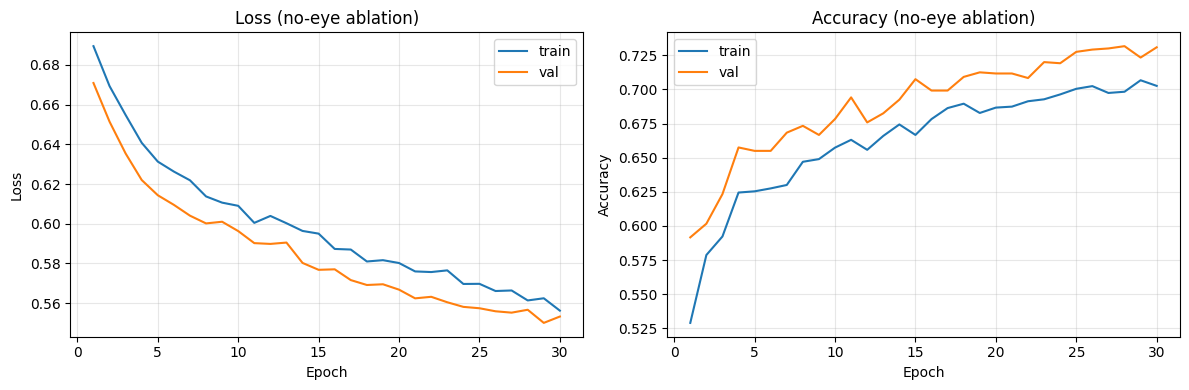

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_x, history["train_loss"], label="train")
ax1.plot(epochs_x, history["val_loss"], label="val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss (no-eye ablation)")
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(epochs_x, history["train_acc"], label="train")
ax2.plot(epochs_x, history["val_acc"], label="val")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("Accuracy (no-eye ablation)")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "face_no_eye_training_curves.png", dpi=120)
plt.show()


## 6. Test set evaluation

Same test set as the main face notebook (same SEED, same split). The
accuracy here is directly comparable to the 79.17% achieved with the
full feature set.


In [12]:
model.load_state_dict(torch.load(BEST_WEIGHTS_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(DEVICE)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(y.tolist())
        all_probs.extend(probs[:, 1].cpu().tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc = accuracy_score(all_labels, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="binary", pos_label=1
)

print(f"Test set: {len(all_labels):,} images")
print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}  (positive class = drowsy)")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\n" + classification_report(
    all_labels, all_preds, target_names=["non_drowsy", "drowsy"], digits=4
))


Test set: 1,200 images

Accuracy:  0.7092
Precision: 0.6865  (positive class = drowsy)
Recall:    0.7700
F1-score:  0.7258

              precision    recall  f1-score   support

  non_drowsy     0.7381    0.6483    0.6903       600
      drowsy     0.6865    0.7700    0.7258       600

    accuracy                         0.7092      1200
   macro avg     0.7123    0.7092    0.7081      1200
weighted avg     0.7123    0.7092    0.7081      1200



C:\Users\leonf\AppData\Local\Temp\ipykernel_23052\1254422696.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_WEIGHTS_PATH, map_loca

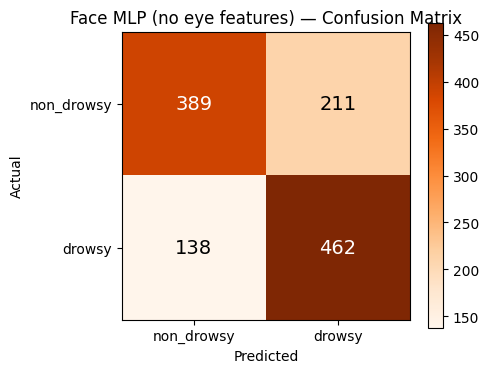

In [13]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Oranges")   # different colour to distinguish from main
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["non_drowsy", "drowsy"])
ax.set_yticklabels(["non_drowsy", "drowsy"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Face MLP (no eye features) — Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=14)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "face_no_eye_confusion_matrix.png", dpi=120)
plt.show()


## 7. Comparison with the main face model

This is the key cell. We summarise the two configurations side by side
to quantify exactly how much of the original face model's performance was
attributable to eye-region features.


In [14]:
# Plug in the actual main-notebook test metrics for direct comparison.
# These were the results from 02_face_training.ipynb on the same test set.
MAIN_FACE_ACCURACY  = 0.7917
MAIN_FACE_PRECISION = 0.7936
MAIN_FACE_RECALL    = 0.7883
MAIN_FACE_F1        = 0.7910

comparison = pd.DataFrame({
    "Metric":      ["Accuracy", "Precision", "Recall", "F1-score"],
    "Full face (6 features)":   [MAIN_FACE_ACCURACY, MAIN_FACE_PRECISION, MAIN_FACE_RECALL, MAIN_FACE_F1],
    "No-eye (4 features)":      [acc, prec, rec, f1],
    "Difference (pp)":          [
        round((MAIN_FACE_ACCURACY  - acc)  * 100, 2),
        round((MAIN_FACE_PRECISION - prec) * 100, 2),
        round((MAIN_FACE_RECALL    - rec)  * 100, 2),
        round((MAIN_FACE_F1        - f1)   * 100, 2),
    ],
})
print(comparison.to_string(index=False))


   Metric  Full face (6 features)  No-eye (4 features)  Difference (pp)
 Accuracy                  0.7917             0.709167             8.25
Precision                  0.7936             0.686478            10.71
   Recall                  0.7883             0.770000             1.83
 F1-score                  0.7910             0.725844             6.52


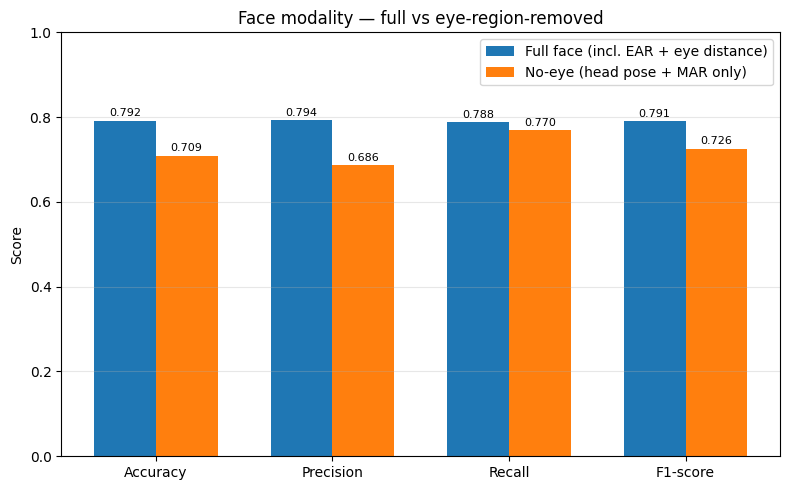

In [16]:
# Bar chart visualising the gap
fig, ax = plt.subplots(figsize=(8, 5))
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
full   = [MAIN_FACE_ACCURACY, MAIN_FACE_PRECISION, MAIN_FACE_RECALL, MAIN_FACE_F1]
no_eye = [acc, prec, rec, f1]

x = np.arange(len(metrics))
w = 0.35
ax.bar(x - w/2, full,   w, label="Full face (incl. EAR + eye distance)")
ax.bar(x + w/2, no_eye, w, label="No-eye (head pose + MAR only)")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Face modality — full vs eye-region-removed")
ax.legend()
ax.grid(alpha=0.3, axis="y")
for i in range(len(metrics)):
    ax.text(i - w/2, full[i] + 0.01,   f"{full[i]:.3f}",   ha="center", fontsize=8)
    ax.text(i + w/2, no_eye[i] + 0.01, f"{no_eye[i]:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "face_ablation_comparison.png", dpi=120)
plt.show()


## 8. Summary

**Two trained models, identical except for the input feature set:**

- **Main face model** (`models/face_mlp.pt`): 6 features including EAR and inter-eye distance. Reported in dissertation §4.3.
- **No-eye ablation** (`models/face_mlp_no_eye.pt`): same architecture, head pose + MAR only. Reported in dissertation §4.3 / §5.2 as supporting evidence for the literature claim that face-based detectors substantially rely on ocular cues.

### What goes in the dissertation from this notebook
- Comparison table from §7 (accuracy gap with and without eye features)
- `face_ablation_comparison.png` bar chart
- A paragraph in the Discussion (§5.2) interpreting the ablation result in light of Wang et al. (2016) and Section 2.5 of the literature review.

### What this experiment proves
If the no-eye model performs substantially worse than the full-face model
(expected: 60-65% vs 79%), this is direct empirical support for the
methodological observation in your literature review that face-based
fatigue detection systems often rely heavily on ocular features rather
than on independent facial behaviour cues.

If the no-eye model performs **similarly** to the full-face model, that
would be a more surprising finding — it would suggest that head pose and
MAR carry more independent information than the literature suggests.
Either outcome is interpretable and supports the dissertation's narrative.
